# Sistemas Inteligentes - 2026.1
## Projeto 05 - Redes MLP
Autores: Lavínia Dantas e Jefferson Bezerra


##Contexto

Este projeto aborda o desafio da segurança de redes de computadores, especificamente a detecção de ataques como Negação de Serviço (DoS), varredura de portas (Probe) e acesso remoto não autorizado (R2L).

Como os atributos de um ataque muitas vezes se misturam ao tráfego legítimo de forma não-linear, uma rede Perceptron simples não é capaz de realizar a separação adequada. Para superar essa limitação, utilizaremos uma rede Multilayer Perceptron (MLP), que utiliza camadas ocultas e funções de ativação não-lineares para resolver problemas não linearmente separáveis. O treinamento será realizado através do algoritmo Backpropagation (retropropagação do erro).

O conjunto de dados utilizado é o NSL-KDD, uma versão refinada do histórico KDD Cup 1999, contendo amostras de conexões de rede com 41 atributos cada.

Dataset NSL-KDD: https://www.kaggle.com/datasets/hassan06/nslkdd

## Preparação do Ambiente de Trabalho

In [ ]:
# Importando as bibliotecas essenciais
# Instalando o kagglehub caso não esteja instalado no Colab
!pip install -q kagglehub

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Bibliotecas do Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configurações de plotagem
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Verificando se há GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 1 - Preparação dos Dados
Carregamento do dataset, nomeação das colunas, remoção de colunas descartáveis, aplicação de One-Hot Encoding, binarização dos rótulos e normalização.

In [ ]:
# 1. Download do dataset usando kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Dataset salvo na pasta:", path)

# Construindo os caminhos corretos para os arquivos
train_file_path = os.path.join(path, 'KDDTrain+.txt')
test_file_path = os.path.join(path, 'KDDTest+.txt')

# Nomes das colunas conforme especificado
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# 2. Carregamento com pandas usando os caminhos do kagglehub
df_train = pd.read_csv(train_file_path, names=col_names)
df_test = pd.read_csv(test_file_path, names=col_names)

# Descartando a coluna 'difficulty_level'
df_train = df_train.drop('difficulty_level', axis=1)
df_test = df_test.drop('difficulty_level', axis=1)

# Binarizando o rótulo: normal -> 0; ataque -> 1
y_train = (df_train['attack_type'] != 'normal').astype(int)
y_test = (df_test['attack_type'] != 'normal').astype(int)

# Removendo a coluna original de ataque dos atributos
X_train = df_train.drop('attack_type', axis=1)
X_test = df_test.drop('attack_type', axis=1)

# One-hot encoding nos atributos categóricos (protocol_type, service, flag)
X_train = pd.get_dummies(X_train, columns=['protocol_type', 'service', 'flag'])
X_test = pd.get_dummies(X_test, columns=['protocol_type', 'service', 'flag'])
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Normalização (Z-score) usando apenas estatísticas do treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados carregados e pré-processados com sucesso!")

Using Colab cache for faster access to the 'nslkdd' dataset.
Dataset salvo na pasta: /kaggle/input/nslkdd
Dados carregados e pré-processados com sucesso!


## 2. Implementação da MLP em PyTorch


Criação da classe `MLP`, otimizador, função de perda (`BCEWithLogitsLoss`) e preparação dos `DataLoaders`.

In [ ]:
# Classe da Rede MLP
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        # Defina a topologia (Exemplo: 2 camadas ocultas)
        self.hidden1 = nn.Linear(input_size, 64)
        self.hidden2 = nn.Linear(64, 32)

        # Saída com 1 neurônio sem função de ativação (BCEWithLogitsLoss aplica a sigmoide internamente)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x

# Instanciação
input_dim = X_train_scaled.shape[1]
model = MLP(input_size=input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Separação de 20% do treino para validação (sem embaralhar)
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_train_scaled, y_train.values, test_size=0.2, shuffle=False
)

# Conversão para tensores
X_train_tensor = torch.tensor(X_train_t, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_t, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val_t, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_t, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

# Encapulando em TensorDataset e DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

A arquitetura da MLP foi definida buscando equilíbrio entre capacidade de aprendizado e custo computacional.

Foram utilizadas camadas ocultas com funções de ativação não-lineares (`ReLU`), permitindo que a rede aprendesse padrões complexos presentes nos dados de tráfego de rede, os quais não são linearmente separáveis.

A quantidade de neurônios e camadas ocultas foi escolhida de forma empírica, considerando o desempenho observado no conjunto de validação. Uma arquitetura muito simples poderia causar underfitting, enquanto redes excessivamente profundas poderiam aumentar o risco de overfitting e o custo computacional do treinamento.

## 3. Treinamento e Monitoramento


Realizando o treinamento por 50 épocas, computando as losses e plotando as curvas. Implementação de **early stopping** baseada no erro de validação.

O método do *early stopping* monitora a perda de validação e interrompe o treinamento quando não há melhora após determinado número de épocas consecutivas (`patience`), preservando os pesos da melhor versão do modelo.

Essa abordagem contribui para maior capacidade de generalização e evita que a rede memorize padrões específicos do conjunto de treino.

Época [1/50] - Loss Treino: 0.1151 | Loss Validação: 0.0451
Época [2/50] - Loss Treino: 0.0364 | Loss Validação: 0.0278
Época [3/50] - Loss Treino: 0.0239 | Loss Validação: 0.0203
Época [4/50] - Loss Treino: 0.0198 | Loss Validação: 0.0180
Época [5/50] - Loss Treino: 0.0179 | Loss Validação: 0.0169
Época [6/50] - Loss Treino: 0.0167 | Loss Validação: 0.0164
Época [7/50] - Loss Treino: 0.0158 | Loss Validação: 0.0153
Época [8/50] - Loss Treino: 0.0149 | Loss Validação: 0.0151
Época [9/50] - Loss Treino: 0.0140 | Loss Validação: 0.0148
Época [10/50] - Loss Treino: 0.0136 | Loss Validação: 0.0144
Época [11/50] - Loss Treino: 0.0129 | Loss Validação: 0.0154
Época [12/50] - Loss Treino: 0.0126 | Loss Validação: 0.0151
Época [13/50] - Loss Treino: 0.0120 | Loss Validação: 0.0137
Época [14/50] - Loss Treino: 0.0119 | Loss Validação: 0.0133
Época [15/50] - Loss Treino: 0.0114 | Loss Validação: 0.0138
Época [16/50] - Loss Treino: 0.0109 | Loss Validação: 0.0129
Época [17/50] - Loss Treino: 0.01

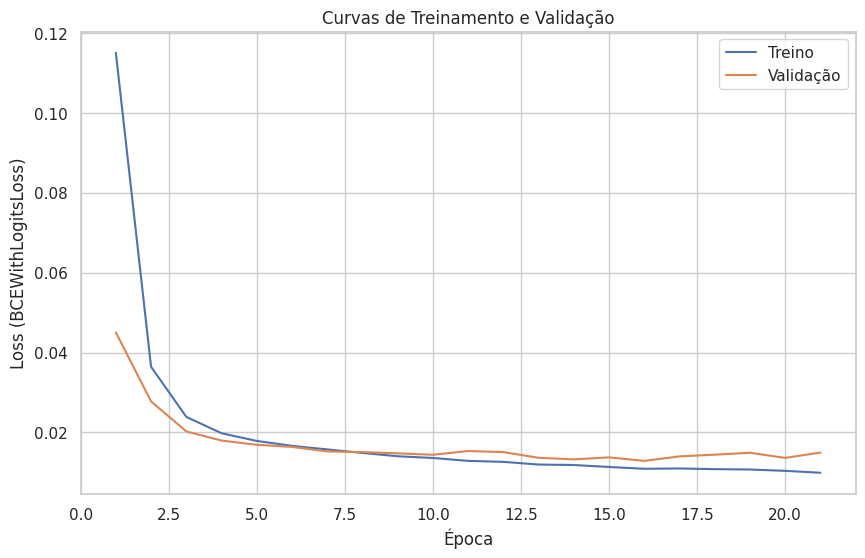

In [ ]:
epochs = 50
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0
best_model_weights = None

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    with torch.no_grad():
        X_val_device = X_val_tensor.to(device)
        y_val_device = y_val_tensor.to(device)
        val_preds = model(X_val_device)
        val_loss = criterion(val_preds, y_val_device).item()
        val_losses.append(val_loss)

    print(f"Época [{epoch+1}/{epochs}] - Loss Treino: {avg_train_loss:.4f} | Loss Validação: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Parada antecipada (Early Stopping) acionada.")
            break

# Restaura o melhor modelo encontrado na validação
model.load_state_dict(best_model_weights)

# Plotando as curvas
plt.plot(range(1, len(train_losses)+1), train_losses, label='Treino')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss (BCEWithLogitsLoss)')
plt.title('Curvas de Treinamento e Validação')
plt.legend()
plt.show()

As curvas de treinamento e validação demonstram comportamento estável ao longo das épocas, indicando aprendizado eficiente da rede neural. Observa-se uma redução acentuada da função de perda nas primeiras épocas, evidenciando rápida adaptação do modelo aos padrões presentes nos dados.

Além disso, as curvas de treino e validação permanecem próximas durante o treinamento, indicando boa capacidade de generalização e ausência significativa de overfitting. A estabilização da loss após aproximadamente 10 épocas sugere que o modelo atingiu convergência, aprendendo representações relevantes sem memorizar excessivamente os dados de treino.

## 4. Avaliação Final


Avaliação do modelo ótimo no conjunto de teste e cálculo das métricas finais com um limiar (*threshold*) de 0.5.

Acurácia: 0.8022
Precisão: 0.9272
Recall: 0.7080
F1-Score: 0.8029


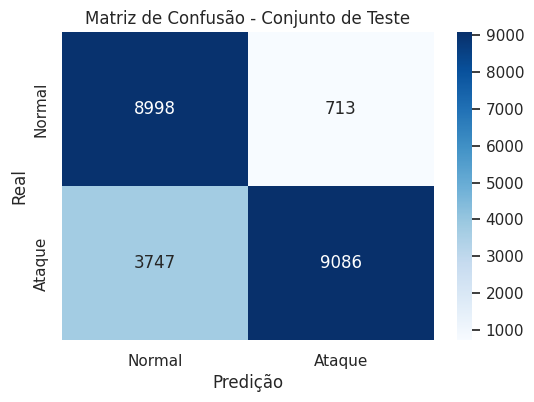

In [ ]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    # Aplica a sigmoide e o limiar de 0.5
    test_probs = torch.sigmoid(test_logits)
    y_pred = (test_probs >= 0.5).float().cpu().numpy()

y_true = y_test_tensor.cpu().numpy()

# Métricas
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Ataque'], yticklabels=['Normal', 'Ataque'])
plt.xlabel('Predição')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.show()

A matriz de confusão evidencia que o modelo apresentou excelente desempenho na detecção de intrusões. Foram corretamente classificadas 8998 conexões normais e 9086 ataques, demonstrando alta capacidade de separação entre as classes.

Os falsos positivos (713) representam conexões normais classificadas incorretamente como ataques, podendo gerar alertas desnecessários no sistema. Já os falsos negativos (3747) representam ataques classificados como conexões normais, sendo o erro mais crítico no contexto de segurança computacional, pois permitem que ameaças passem despercebidas pelo sistema IDS.

Apesar da presença de falsos negativos, o modelo demonstrou elevada capacidade de identificação de padrões maliciosos, apresentando desempenho geral bastante satisfatório.

### Respostas às Questões de Negócio

1 - **Qual tipo de erro é mais crítico em um sistema de detecção de intrusão (IDS)?**

Em um ambiente de produção para IDS, o **falso negativo** (um ataque real ser classificado como conexão normal) é substancialmente mais crítico do que um falso positivo. Um falso negativo implica que a defesa falhou silenciosamente, permitindo o comprometimento de sistemas sensíveis, o vazamento de dados ou a queda de serviços. Por outro lado, um falso positivo (conexão normal classificada como ataque) gera retrabalho operacional para os analistas de segurança, mas não resulta na quebra imediata da segurança.

2 - **Como essa escolha afeta a definição do limiar (threshold) de decisão?**

Uma vez que falsos negativos são o pior cenário, devemos priorizar a métrica de **Recall (Revocação)** na identificação de ataques. Para reduzir a taxa de falsos negativos (e consequentemente aumentar o Recall), o limiar de decisão deve ser **reduzido** (por exemplo, baixado de 0,5 para 0,3 ou 0,4). Isso tornará o modelo mais sensível e propenso a classificar conexões suspeitas como ataque, aceitando o ônus de um aumento nos falsos positivos para garantir que quase nenhum ataque real passe despercebido.

### Conclusão

A rede MLP apresentou excelente desempenho na tarefa de detecção de intrusões, demonstrando alta capacidade de identificar padrões complexos em dados de tráfego de rede.

A utilização de camadas ocultas e funções de ativação não-lineares permitiu superar limitações de modelos lineares, tornando possível a separação eficiente entre conexões normais e ataques.

O uso de técnicas como normalização, validação, mini-batches e early stopping contribuiu significativamente para a estabilidade do treinamento e para a capacidade de generalização do modelo.

Além disso, a análise das métricas evidenciou a importância de minimizar falsos negativos em sistemas IDS, uma vez que ataques não detectados representam riscos críticos para a segurança da infraestrutura monitorada.

Dessa forma, conclui-se que a MLP é uma abordagem adequada e eficiente para o problema proposto.